In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-10 16:10:19.831334


# Fine-tuned filtering

* Transcript count: just remove cells in top quarter of percent for each sample
* Area: remove cells  > 300 sq. micron in size
* Doublet scores: remove cells scored > 98th percentile using scrublet

In [2]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import anndata as ad
import session_info

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
base_dir = Path('/home/workspace/projects/drg')
input_dir = os.path.join(base_dir, 'data/h5ad/export_01/03_scrublet')

output_dir = os.path.join(base_dir, 'data/h5ad/export_01/04_filtered')
os.makedirs(output_dir, exist_ok = True)

In [5]:
mapping = {
    'TMA00303': 1,
    'TMA00304': 1,
    'TMA00305': 2,
    'TMA00306': 2
}

## Filter

In [6]:
sample_files = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.h5ad')]
adata_list = [sc.read_h5ad(f) for f in sample_files] #sc.read is deprecated

adata_list

[AnnData object with n_obs × n_vars = 21501 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 32284 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned

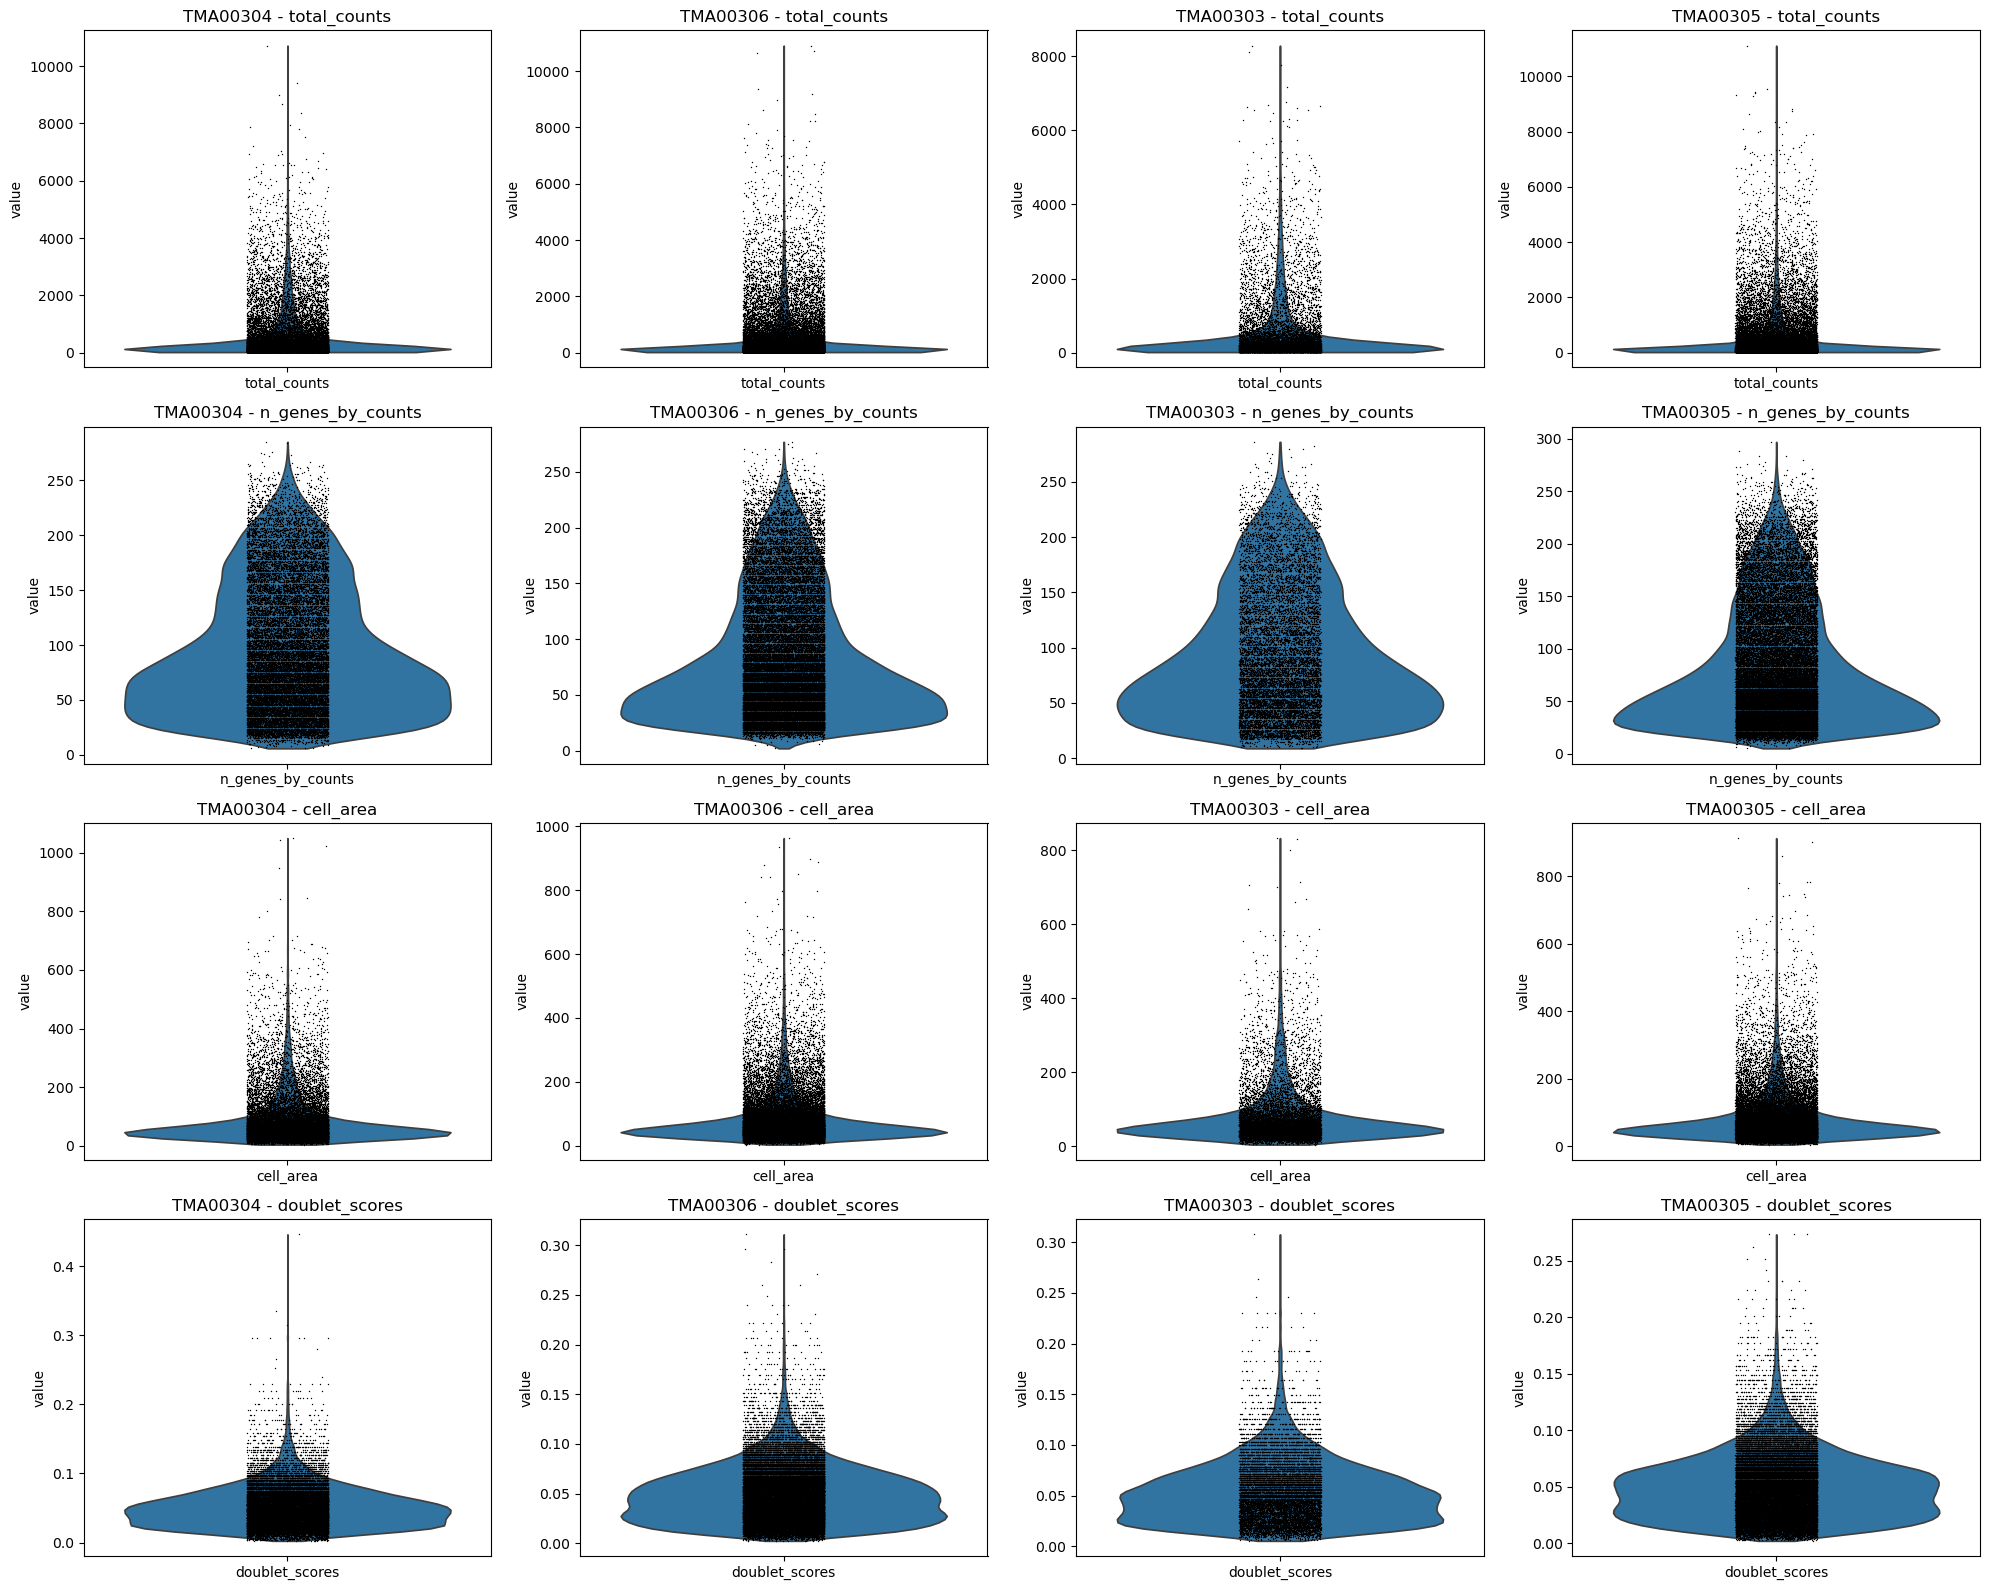

In [7]:
features = ['total_counts', 'n_genes_by_counts', 'cell_area', 'doublet_scores']

# Create subplots
fig, axes = plt.subplots(len(features), len(adata_list), figsize=(len(adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

## Filters

In [8]:
# transcript count -- just remove extreme outliers (top quarter of a percent)
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before total_counts ceiling threshold: {adata.shape}")
    total_counts_ceiling = adata.obs['total_counts'].quantile(0.9975)
    adata_list[i] = adata[adata.obs['total_counts'] < total_counts_ceiling, :]
    print(f"Dataset {i} shape after total_counts ceiling threshold: {adata_list[i].shape}")

Dataset 0 shape before total_counts ceiling threshold: (21501, 480)
Dataset 0 shape after total_counts ceiling threshold: (21447, 480)
Dataset 1 shape before total_counts ceiling threshold: (32284, 480)
Dataset 1 shape after total_counts ceiling threshold: (32203, 480)
Dataset 2 shape before total_counts ceiling threshold: (11408, 480)
Dataset 2 shape after total_counts ceiling threshold: (11379, 480)
Dataset 3 shape before total_counts ceiling threshold: (33118, 480)
Dataset 3 shape after total_counts ceiling threshold: (33035, 480)


In [9]:
# Area -- 180 seems to exclude most doublets in xenium explorer
# Changed to 300 to be more inclusive
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before area ceiling threshold: {adata.shape}")
    adata_list[i] = adata[adata.obs['cell_area'] < 300, :].copy()
    print(f"Dataset {i} shape after area ceiling threshold: {adata_list[i].shape}")

Dataset 0 shape before area ceiling threshold: (21447, 480)
Dataset 0 shape after area ceiling threshold: (20817, 480)
Dataset 1 shape before area ceiling threshold: (32203, 480)
Dataset 1 shape after area ceiling threshold: (31500, 480)
Dataset 2 shape before area ceiling threshold: (11379, 480)
Dataset 2 shape after area ceiling threshold: (11134, 480)
Dataset 3 shape before area ceiling threshold: (33035, 480)
Dataset 3 shape after area ceiling threshold: (32440, 480)


In [10]:
# Doublet scores -- remove cells scoring in top 2% for doublets
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before doublet_scores ceiling threshold: {adata.shape}")
    doublet_scores_ceiling = adata.obs['doublet_scores'].quantile(0.98)
    adata_list[i] = adata[adata.obs['doublet_scores'] < doublet_scores_ceiling, :]
    print(f"Dataset {i} shape after doublet_scores ceiling threshold: {adata_list[i].shape}")

Dataset 0 shape before doublet_scores ceiling threshold: (20817, 480)
Dataset 0 shape after doublet_scores ceiling threshold: (20395, 480)
Dataset 1 shape before doublet_scores ceiling threshold: (31500, 480)
Dataset 1 shape after doublet_scores ceiling threshold: (30839, 480)
Dataset 2 shape before doublet_scores ceiling threshold: (11134, 480)
Dataset 2 shape after doublet_scores ceiling threshold: (10849, 480)
Dataset 3 shape before doublet_scores ceiling threshold: (32440, 480)
Dataset 3 shape after doublet_scores ceiling threshold: (31771, 480)


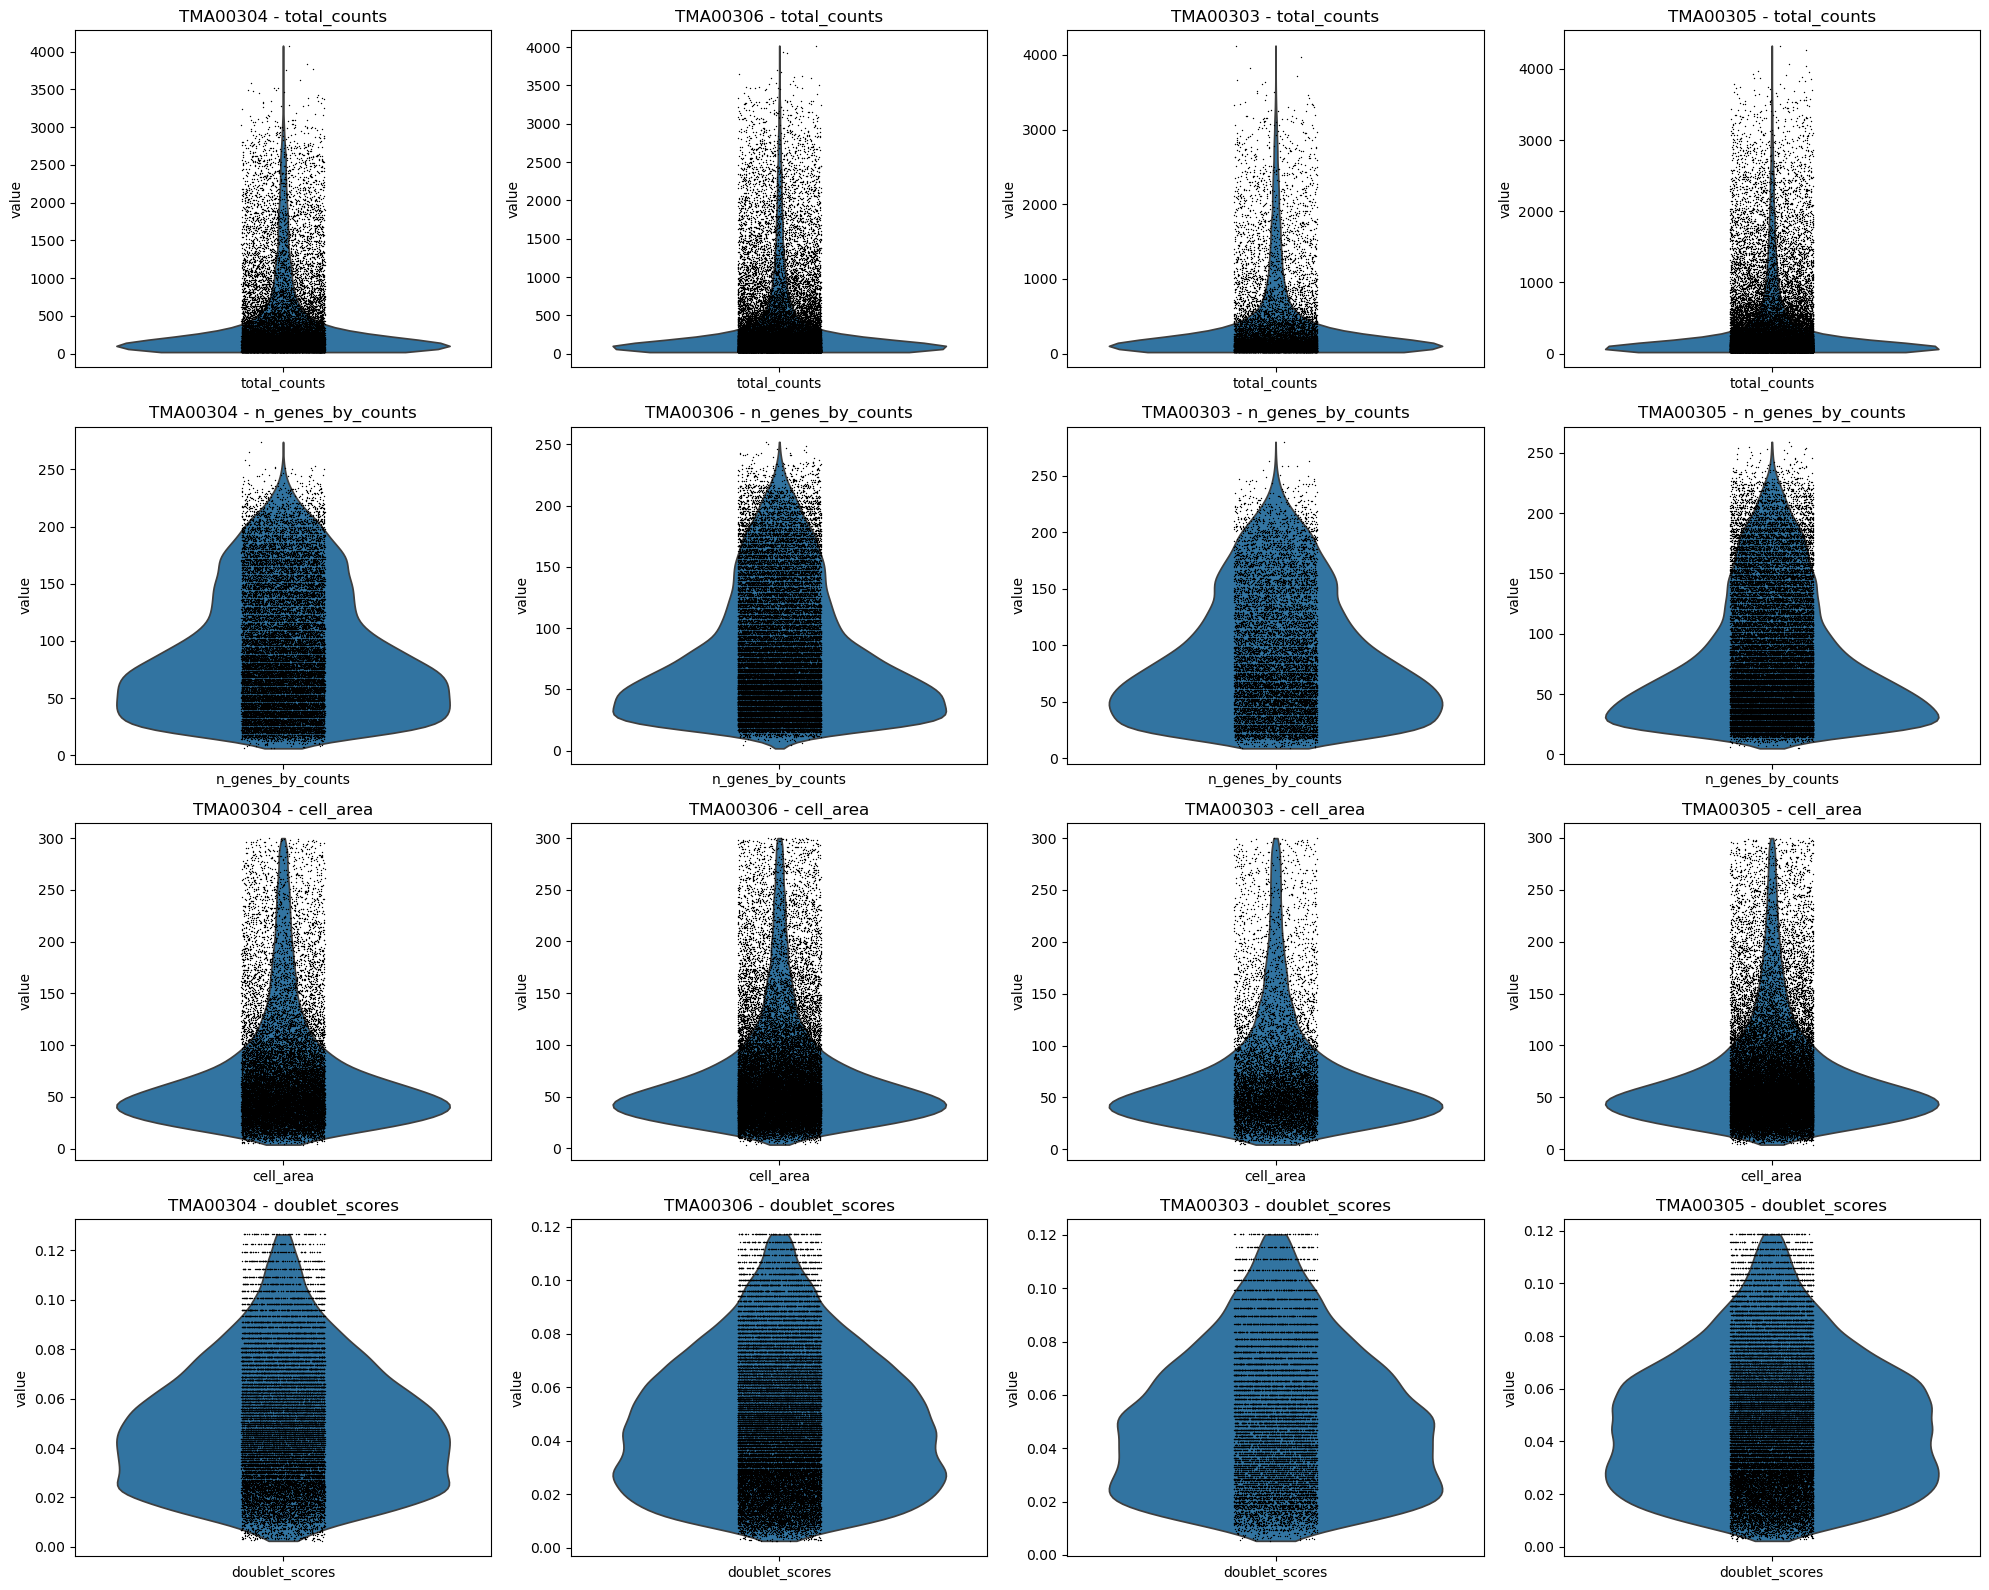

In [11]:
fig, axes = plt.subplots(len(features), len(adata_list), figsize=(len(adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['output_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

## Concatenate

In [12]:
adata = ad.concat(adata_list, 
                  join="outer", 
                  label = 'batch', # suffix of adata.obs_names should match batch
                  index_unique="-")

In [13]:
adata

AnnData object with n_obs × n_vars = 93854 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch'
    obsm: 'spatial'

In [14]:
adata.obs.output_id.value_counts()

output_id
TMA00305    31771
TMA00306    30839
TMA00304    20395
TMA00303    10849
Name: count, dtype: int64

# Complete metadata

Add slide information

In [15]:
adata.obs['slide'] = adata.obs['output_id'].map(mapping)
adata.obs.slide.value_counts()

slide
2    62610
1    31244
Name: count, dtype: int64

## Normalize

In [16]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e6)
adata.layers["normalized_1e6"] = adata.X.copy()

sc.pp.log1p(adata)
adata.raw = adata.copy() # freeze log1p in raw slot
adata.layers["log1p"] = adata.X.copy()

In [17]:
adata.layers

Layers with keys: counts, normalized_1e6, log1p

## Export

In [18]:
filename = os.path.join(output_dir, 'adata-filtered.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata.write_h5ad(filename, compression='gzip')
print(f'Filtered, concatenated adata saved to: {filename}')

Filtered, concatenated adata saved to: /home/workspace/projects/drg/data/h5ad/export_01/04_filtered/adata-filtered.h5ad


## Session info

In [19]:
print('active IDE: sc-spatial')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial
active conda environment: sc-spatial
